# Phenotype Curation Step 1: Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

#Load the phenotype data /mnt/c/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_DA-AA_2025_01_23.txt
pheno = pd.read_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_DA-AA_2025_01_23.txt", sep="\t")
#print dimension
print(pheno.shape)





(757, 38)


In [2]:
#first check: col names of interest
# ID,Complete ID# considering extended families (complete),,,,,
#FID,ID # of the family considering extended families,,,,,
#IID,ID # of the sample in the family,,,,,
#FA,ID # of the father  (ex 600-2000),,,,,
#MO,ID # of the mother (ex 600-3001),,,,,
#Sex,"Sex of the subject (1=male, 2=female)",,,,,
#AgeCalc,age of the individual at the recrutement or consent (if the date on recruitment is unavailable) calculated in number of days divided by 365 (date on recruitment - date of birth),,,,,
#AGE,age of the individual at the recruitment (calculated if not present in the initial column),,,,,
# #AgeIncl,age of inclusion of the individual (initial column),,,,,
#SMOK_HIS,"Smoking history, 0=non smoker, 1=the subject smokes for less than one year, 2=he smokes since 1 to 5 years, 3=he smokes since 6 to 10 years, 4=he smokes since 11 to 15 years, 5=he smokes since 16 to 19 years and 6=he smokes since more than 20 years",,,,,
#SMOK_HIS_EQinYR,Equivalent to SMOK_HIS but in range,,,,,
#pass_smok_child_EGEA,"Subject exposed to second hand smoke during childhood (automated calculation) (if the subject is less than 16 years old: childhood = 2 years old or less, if subject is 16 years old or more: childhood = 5 years old or less) 1=No, 2=Yes,0=Unknown",,,,,
#pass_smok_child_5y,"Subject exposed to second hand smoke during childhood (childhood = 5 years old or less): 1=No, 2=Yes,0=Unknown",,,,,
#pass_smok,"Subject exposed to second hand smoke: 1=No, 2=Yes,0=Unknown",,,,,
#pass_smok_IU,"Subject exposed to tobacco smoke during pregnancy (PTS) : 1=No, 2=Yes,0=Unknown",,,,,
#PACK_YR,Pack per year: number of cigarettes per day / 25 * number of years as smoker,,,,,
#SMOK_STA,"Smoking status: non smoker, ex smoker, smoker",,,,,
#SMOK_STA123,"Smoking status, 0=don't know, 1=non smoker, 2=ex smoker, 3=smoker",,,,,
#SMOK_STA123_3M,"Smoking status: unknown= 0, non smoker=1, ex smoker =2 (considered ex-smoker if subject quit smoking for 3 months or more) smoker=3",,,,,
#SMOK_STA123_1Y,"smoking status:  0=unknown, non smoker=1, ex smoker=2 (considered ex smoker if the subject quit smoking for at least 1 year) smoker=3",,,,,

#EOSINO,Blood concentration of eosinophils (in billions x10E9/L),,,,,"CBCs with differential were measured using a Coulter LH 780 hematology analyzer to estimate the proportions of five major cell types in each sample: eosinophils, lymphocytes, neutrophils, monocytes and basophils"
#EOSINOpc,Relative blood concentration of eosinophils (%),,,,,
#LYMPHO,Blood concentration of lymphocytes (in billions x10E9/L),,,,,
#LYMPHOpc,Relative blood concentration of lymphocytes (%),,,,,
#MONO,Blood concentration of monocytes (in billions x10E9/L),,,,,
#MONOpc,Relative blood concentration of monocytes (%),,,,,
#NEUTRO,Blood concentration of neutrophils (in billions x10E9/L),,,,,
#NEUTROpc,Relative blood concentration of neutrophils (%),,,,,
#BASO,Blood concentration of basophils (in billions x10E9/L),,,,,
#BASOpc,Relative blood concentration of basophils (%),,,,,
##extract these columns from pheno data
#print the column names of pheno

#second check: the col names of the data available
print(pheno.columns)

#
#   ID,Complete ID# considering extended families (complete),,,,,
#   Sex,"Sex of the subject (1=male, 2=female)",,,,,
#   date_birth,Birth date (in numbers),,,,,
#   AGE,age of the individual at the recruitment (calculated if not present in the initial column),,,,,
#   AgeCalc,age of the individual at the recrutement or consent (if the date on recruitment is unavailable) calculated in number of days divided by 365 (date on recruitment - date of birth),,,,,
#   DX_AST,"Asthma index, corresponds to the official diagnosis of a doctor. 1=no diagnosis of asthma, 2=diagnosis of asthma. ",,,,,
#   AGE_ON,Age of onset,,,,,
#   DX_ATOall,"Atopic index, 2=allergic to one or more allergen, 1=not allergic, na=no classification. This column includes the data from the skin prick test and also from the questionnaire (self-reported).",,,,,
#   DX_ATOspt_2022,"values updated by Marie_Pier Bouchard in 2022 after revision of patient's files. Atopic index, 2=allergic to one or more allergen, 1=not allergic, na=no classification. This column includes the data from the skin prick test only.",,,,,
#   DX_AST_ATO,"Asthma and atopy index, 2=diagnosis of asthma (DX_AST) AND the subjects is allergic (DX_ATOall), 1=don't reach one or two of the latters critaria, na=no classification",,,,,
#   DX_ASTATO2,"Asthma and atopy index, 2=diagnosis of asthma (DX_AST) AND the subjects is allergic (DX_ATOall), 1=don't reach both of the latters critaria, na=no classification",,,,,
#   DX_AST_ATO2_2022,"values of allergy updated by Marie_Pier Bouchard in 2022 after revision of patient's files. Asthma and atopy index, 2=diagnosis of asthma (DX_AST) AND the subjects is allergic (DX_ATOall), 1=don't reach both of the latters critaria, na=no classification",,,,,
#   PH_RHIN,"Personal history of rhinitis, 2=the individual suffer or have already suffered from rhinitis, 1=no rhinitis",,,,,
#   PH_DERM,"Personal history of dermatitis 2= the individual suffer or have already suffered from urticaria or eczema, 1= no eczema or urticaria",,,,,
#   AST_ATO_DERM,"Subject with asthma (DX_AST = 2) atopy (DX_ATOall = 2) and dermatitis (PH_DERM = 2) controls have dermatitis, atopy or asthma (but not all) or no asthma, no atopy and no rhinitis",,,,,
#   AST_ATO_DERM2,"Subject with asthma (DX_AST = 2) atopy (DX_ATOall = 2) and dermatitis (PH_DERM = 2) controls have no dermatitis, no atopy nor asthma",,,,,
#   AST_ATO_derm2_2022
#   Groupe_4 facteurs
#   IGE,Amount of IgE in blood (µg/L) ,,,,,
#   IGE_ln
#   PC20_64,"Provocative concentration of methacholine that induces a 20% fall in FEV1 (mg/ml) with a maximum value of 64 mg/ml because some of the patients were not evaluated with bigger concentrations. To be precise, we remove the 17 mg/ml data from this column as we don't know if the patient should have obtain a value between 17 and 64 mg/ml.",,,,,
#   PC20_64ln
#   pcpred_FEV1,Forced expiratory volume in one second (% of predicted value) (baseline data from the pre-BD spirometry or the methacholine challenge),,,,,
#   FEV1/FVC,Ratio of the Forced expiratory volume in one second on the Forced vital capacity (%) (from the respiratory exam) (baseline data from the pre-BD spirometry or the methacholine challenge),,,,,
#   SMOK_STA123_1Y,"smoking status:  0=unknown, non smoker=1, ex smoker=2 (considered ex smoker if the subject quit smoking for at least 1 year) smoker=3",,,,,
#   Non-smoker
#   Ex-smoker
#   Smoker
#   EOSINO,Blood concentration of eosinophils (in billions x10E9/L),,,,,"CBCs with differential were measured using a Coulter LH 780 hematology analyzer to estimate the proportions of five major cell types in each sample: eosinophils, lymphocytes, neutrophils, monocytes and basophils"
#   EOSINOpc,Relative blood concentration of eosinophils (%),,,,,
#   LYMPHO,Blood concentration of lymphocytes (in billions x10E9/L),,,,,
#    LYMPHOpc,Relative blood concentration of lymphocytes (%),,,,,
#  MONO,Blood concentration of monocytes (in billions x10E9/L),,,,,
#  MONOpc,Relative blood concentration of monocytes (%),,,,,
#  NEUTRO,Blood concentration of neutrophils (in billions x10E9/L),,,,,
#  NEUTROpc,Relative blood concentration of neutrophils (%),,,,,
#  BASO,Blood concentration of basophils (in billions x10E9/L),,,,,
# BASOpc,Relative blood concentration of basophils (%),,,,,

#print summary of ID




Index(['ID', 'Sex', 'date_birth', 'Age', 'AgeCalc', 'DX_AST', 'AGE_ON',
       'DX_ATOall', 'DX_ATOspt_2022', 'DX_AST_ATO', 'DX_ASTATO2',
       'DX_ASTATO2_2022', 'PH_RHIN', 'PH_DERM', 'AST_ATO_derm',
       'AST_ATO_derm2', 'AST_ATO_derm2_2022', 'Groupe_4 facteurs', 'IgE',
       'IGE_ln', 'PC20_64', 'PC20_64ln', 'pcpred_FEV1', 'FEV1_FVC',
       'SMOK_STA123_1Y', 'Non-smoker', 'Ex-smoker', 'Smoker', 'EOSINO',
       'EOSINOpc', 'LYMPHO', 'LYMPHOpc', 'MONO', 'MONOpc', 'NEUTRO',
       'NEUTROpc', 'BASO', 'BASOpc'],
      dtype='object')


## Response Variable Selection

### Allergic asthma (AA)

we use this variable as the response variable in Aim I analysis for AA versus control.

*  DX_ASTATO2_2022, "values of allergy updated by Marie_Pier Bouchard in 2022 after revision of patient's files. Asthma and atopy index, 2=diagnosis of asthma (DX_AST) AND the subjects is allergic (DX_ATOall), 1=don't reach both of the latters critaria, na=no classification",,,,,


### Allergic dermatitis (AD)

we use this variable as the response variable in Aim I analysis for AD versus control.


* PH_DERM,"Personal history of dermatitis 2= the individual suffer or have already suffered from urticaria or eczema, 1= no eczema or urticaria",,,,,

Note that this is due to discussions with AM Madore on the data phenotypes in March, 2025.

## Age 

* AGE,age of the individual at the recruitment (calculated if not present in the initial column),,,,,
* AgeCalc,age of the individual at the recrutement or consent (if the date on recruitment is unavailable) calculated in number of days divided by 365 (date on recruitment - date of birth)

AgeCalc is derived as a continuous numerical value (in years, but with decimal precision), which provides a finer granularity than the integer-valued AGE. This extra precision can be advantageous in methylation analysis where subtle age-related effects might matter. Note that the corelation between AGE and AgeCalc is very high r = 0.998.

* We decide to use AgeCalc instead of Age as the only age variable in the analysis.
* we are not using age_on, age of onset in Aim I analysis.


## sex

* Sex,"Sex of the subject (1=male, 2=female)",,,,, we take this covariates.

## lgE

We will not be using lgE for Aim 1, since IgE is an immune biomarker often elevated in atopic conditions and may lie on the causal pathway between epigenetic changes and the clinical phenotype of AD. In other words, adjusting for IgE might remove some of the signal we want to detect.

## PC20_64

PC20_64 measures airway hyperresponsiveness,  it reflects disease severity or may lie on the causal pathway between the underlying disease process and methylation changes, adjusting for it could remove part of the biological signal we want to capture.


## pcpred_FEV1 and FEV1/FVC

These measures are specific to lung function, they are not directly relevant to AD. Although they are important indicators of asthma severity, they may lie on the causal pathway of the disease. Adjusting for them in the primary analysis might “over-adjust” by removing part of the disease signal. 

## Smoking Status (SMOK_STA123_1Y)

Smoking is a well-known modifier of DNA methylation and can affect respiratory health. It is sensible to include smoking status as a covariate to account for its potential confounding effect.

we will use a dummy variable to represent non-smoker status versus (smokers + Ex-smokers). The reason is that the definition of ex-smokers is ambiguous, some will define ex-smokers as someone who stop smoking since 3 months, or 1 year, etc. Moreover, ex-smokers may have effects on respiratory functions for long time.


## Cell-type covariates

We will use the following cell-type covariates in the analysis:


*   EOSINOpc,Relative blood concentration of eosinophils (%),,,,,
*   LYMPHOpc,Relative blood concentration of lymphocytes (%),,,,,
*  MONOpc,Relative blood concentration of monocytes (%),,,,,
*  NEUTROpc,Relative blood concentration of neutrophils (%),,,,,
* BASOpc,Relative blood concentration of basophils (%),,,,,



Length of the column: 757
count    676.000000
mean       3.540680
std        2.699045
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       22.000000
Name: EOSINOpc, dtype: float64
Number of unique values: 60
Data type: float64
Number of missing values: 81


0.03597767990578081


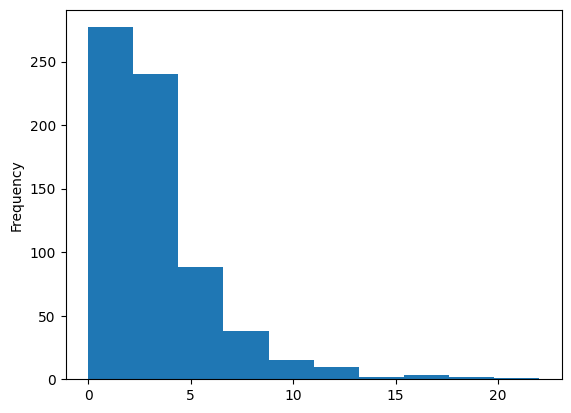

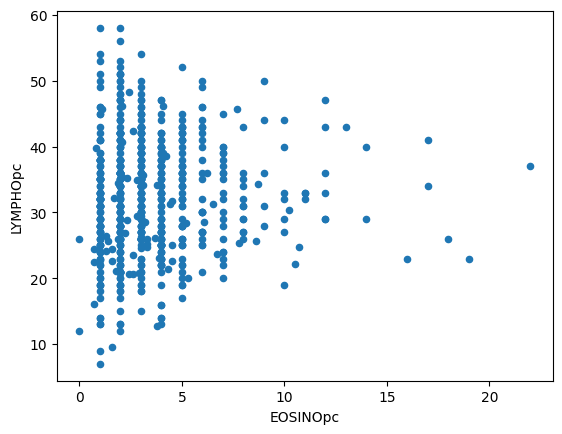

In [3]:

def report_column(column_name):
    
    #print length of the column
    print("Length of the column:", len(pheno[column_name]))
    # Print descriptive statistics
    print(pheno[column_name].describe())
    # Print the number of unique values
    print("Number of unique values:", pheno[column_name].nunique())
    # Print the data type of the column
    print("Data type:", pheno[column_name].dtype)
    #number of missing values
    print("Number of missing values:", pheno[column_name].isnull().sum())
    # plot this column
    pheno[column_name].plot.hist()
    # Show the plot
    

report_column("EOSINOpc")

#plot scatterplot of Age vs EOSINO
pheno.plot.scatter(x="EOSINOpc", y="LYMPHOpc")

#correlation between Age and AgeCalc
print(pheno["EOSINOpc"].corr(pheno["LYMPHOpc"]))


## Cell-type porportion Data correction (March 24, 2025)

Anne-Marie corrected the cell-type proportion data for 2 samples. We incorporated this correction in the data preprocessing step. The corrected values are as follows:


629-0002

EOSINO: 0.3 (4%), LYMPHO: 2.5 (40%), MONO: 0.5 (9%), NEUTRO: 2.9 (46%) and BASO 0 (1%).

There was an error for the BASOpc column in the table and the value should be 1%.

 

871-0001

EOSINO: 0.4 (7%), LYMPHO : 1.7 (26%), MONO : 0.6 (10%), NEUTRO : 3.5 (57%), BASO : 0 (0%)

There was an error for both NEUTRO and NEUTROpc values as they were reversed in the table.



In [8]:
# print the cell-type proportions for the ind: 728-2000 
#print(pheno.loc[pheno["ID"]=="728-0002", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]])
#print(pheno.loc[pheno["ID"]=="728-2000", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]])


count    676.000000
mean     100.151036
std        0.664429
min       97.000000
25%      100.000000
50%      100.000000
75%      101.000000
max      102.000000
Name: total_cell_types, dtype: float64
0.012820787435653559


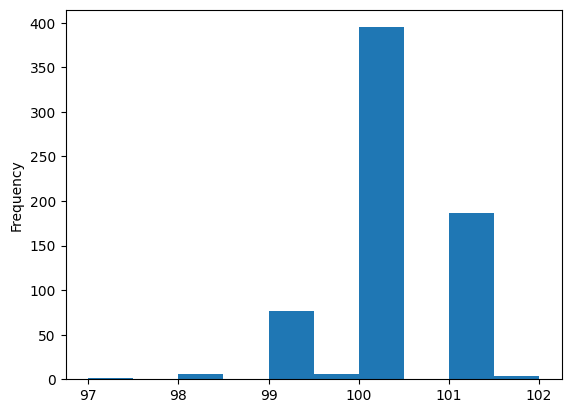

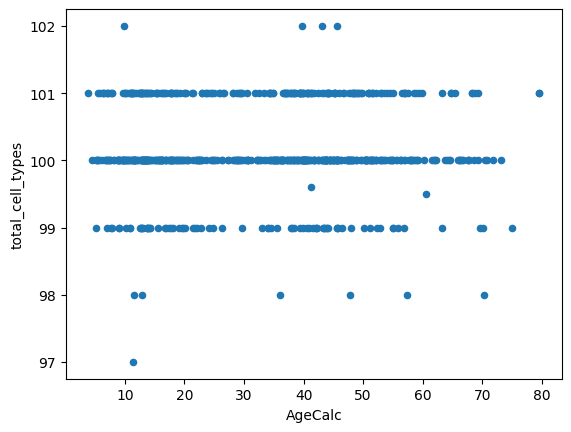

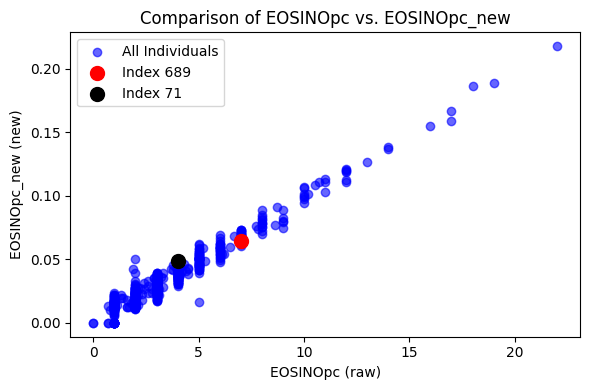

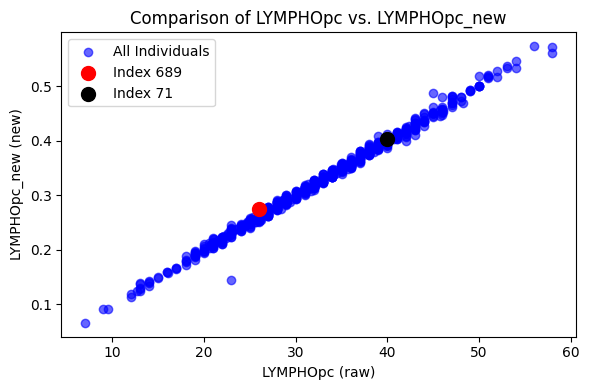

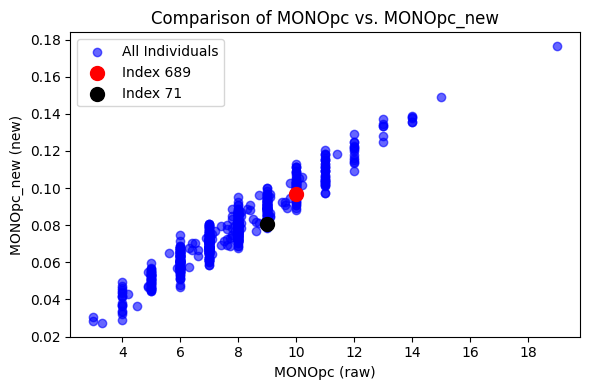

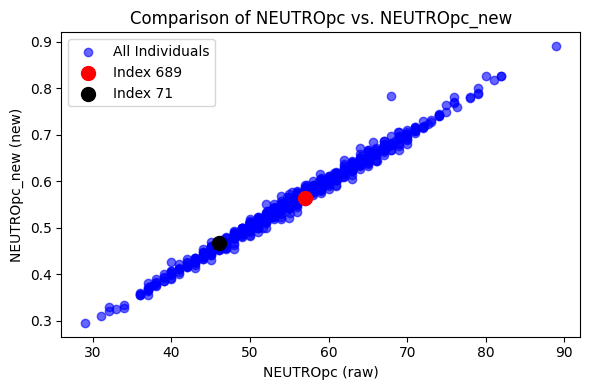

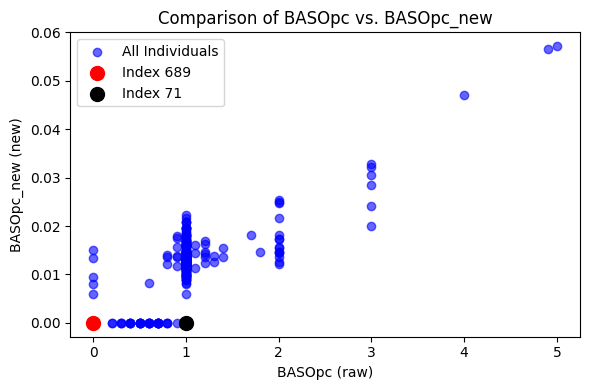

The two dubious individuals are:
871-0001
629-0002


In [9]:

import pandas as pd
import matplotlib.pyplot as plt

#now we create a variable that is the summation of these 5 cell-types:
#EOSINOpc,Relative blood concentration of eosinophils (%),,,,,
#   LYMPHOpc,Relative blood concentration of lymphocytes (%),,,,,
#  MONOpc,Relative blood concentration of monocytes (%),,,,,
#  NEUTROpc,Relative blood concentration of neutrophils (%),,,,,
# BASOpc,Relative blood concentration of basophils (%),,,,,

#replace the BASO value of IID 629-0002 with 0
pheno.loc[pheno["ID"] == "629-0002", "BASO"] = 0
pheno.loc[pheno["ID"] == "629-0002", "BASOpc"] = 1

#correct the NEUTRO value of IID 871-0001
pheno.loc[pheno["ID"] == "871-0001", "NEUTRO"] = 3.5
pheno.loc[pheno["ID"] == "871-0001", "NEUTROpc"] = 57


pheno["total_cell_types"] = pheno["EOSINOpc"] + pheno["LYMPHOpc"] + pheno["MONOpc"] + pheno["NEUTROpc"] + pheno["BASOpc"]
print(pheno["total_cell_types"].describe())
pheno["total_cell_types"].plot.hist()
#plot scatterplot of Age vs total_cell_types
pheno.plot.scatter(x="AgeCalc", y="total_cell_types")
#correlation between Age and total_cell_types
print(pheno["AgeCalc"].corr(pheno["total_cell_types"]))

#print all values of total_cell_types
#print(pheno["total_cell_types"].unique())      
    
    
#print th

# Define the columns of interest
cell_cols = ["EOSINOpc", "EOSINO", "LYMPHOpc", "LYMPHO", "MONOpc", "MONO","NEUTROpc", "NEUTRO","BASOpc", "BASO", "total_cell_types"]


#the 689th and 71th individuals have weird reported cell-type proportions previously

#therefore we will recalculate the cell-type proportions for each indivuals, and check what happened.

#first 
pheno["total_WBC_counts"] = pheno["EOSINO"] + pheno["LYMPHO"] + pheno["MONO"] + pheno["NEUTRO"] + pheno["BASO"]
pheno["EOSINOpc_new"] = pheno["EOSINO"] / pheno["total_WBC_counts"]
pheno["LYMPHOpc_new"] = pheno["LYMPHO"] / pheno["total_WBC_counts"]
pheno["MONOpc_new"] = pheno["MONO"] / pheno["total_WBC_counts"]
pheno["NEUTROpc_new"] = pheno["NEUTRO"] / pheno["total_WBC_counts"]
pheno["BASOpc_new"] = pheno["BASO"] / pheno["total_WBC_counts"]

#now compare the new and old cell-type proportions, draw the scatterplots, on each plot color the 689th and 71th individuals in red

# List of tuples (old_column, new_column)
cell_types = [
    ("EOSINOpc", "EOSINOpc_new"),
    ("LYMPHOpc", "LYMPHOpc_new"),
    ("MONOpc",   "MONOpc_new"),
    ("NEUTROpc", "NEUTROpc_new"),
    ("BASOpc",   "BASOpc_new")
]

# Create scatterplots comparing old and new proportions
for old_col, new_col in cell_types:
    plt.figure(figsize=(6, 4))
    # Plot all individuals in blue
    plt.scatter(pheno[old_col], pheno[new_col], color='blue', alpha=0.6, label='All Individuals')
    
    # Highlight the 689th and 71st individuals in red
    # Using .iloc because these refer to the positional index
    plt.scatter(pheno.iloc[689][old_col], pheno.iloc[689][new_col], color='red', s=100, label='Index 689')
    plt.scatter(pheno.iloc[71][old_col], pheno.iloc[71][new_col], color='black', s=100, label='Index 71')
    
    plt.xlabel(f"{old_col} (raw)")
    plt.ylabel(f"{new_col} (new)")
    plt.title(f"Comparison of {old_col} vs. {new_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()


#print the ID of the 689th and 71th individuals
print("The two dubious individuals are:")
print(pheno.iloc[689]["ID"])
print(pheno.iloc[71]["ID"])



In conclusion, we can see: 


* the two probelamtic samples (629-0002 and 871-0001) are fixed.

* we will use  only the 4 uncorrelated cell-type proportions (EOSINOpc, LYMPHOpc, MONOpc, NEUTROpc) in the analysis. We will not include BASOpc in the analysis because it will induce collinearity with the other cell-type proportions.


count    676.000000
mean     100.151036
std        0.664429
min       97.000000
25%      100.000000
50%      100.000000
75%      101.000000
max      102.000000
Name: total_cell_types, dtype: float64


<Axes: xlabel='AgeCalc', ylabel='total_cell_types'>

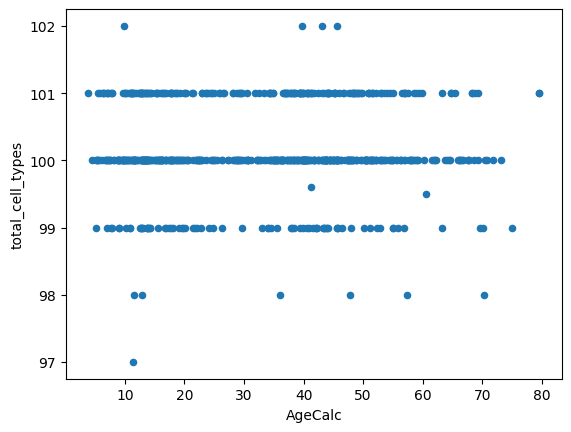

In [10]:
# For individual 689, we will replace the raw NEUTROpc value with 1 - sum(other cell type proportions). 

# Calculate the sum of the other cell type proportions for individual 689
#sum_other_proportions = 100 - (pheno.loc[689, ["EOSINOpc", "LYMPHOpc", "MONOpc", "BASOpc"]].sum())
# Replace the NEUTROpc_new value for individual 689
#pheno.loc[689, "NEUTROpc"] = sum_other_proportions



pheno["total_cell_types"] = pheno["EOSINOpc"] + pheno["LYMPHOpc"] + pheno["MONOpc"] + pheno["NEUTROpc"] + pheno["BASOpc"]
print(pheno["total_cell_types"].describe())



#plot scatterplot of Age vs total_cell_types
pheno.plot.scatter(x="AgeCalc", y="total_cell_types")
#correlation between Age and total_cell_types

# Covariate Selection


Finally, we curate these variables for Aim 1 methylation analysis after first round of data preprocessing.


* Response Variables:


  * AD:  PH_DERM,"Personal history of dermatitis 2= the individual suffer or have already suffered from urticaria or eczema, 1= no eczema or urticaria",,,,,

  * AA: DX_ASTATO2_2022， "values of allergy updated by Marie_Pier Bouchard in 2022 after revision of patient's files. Asthma and atopy index, 2=diagnosis of asthma (DX_AST) AND the subjects is allergic (DX_ATOSep2022), 1=don't reach both of the latters critaria, na=no classification",,,,,

  * AD only: AD, but not AA
  * AA only: AA, but not AD
  * Control: Neither AD nor AA


* Covariates:

    * AgeCalc
    * Sex
    * Smiking status: Smoker vs non-smoker.
    * Cell-type proportions: EOSINOpc, LYMPHOpc, MONOpc, NEUTROpc


In [11]:
#pheno["DX_ATOspt_2022_DERM"] = (pheno["DX_ATOspt_2022"] == 2) & (pheno["PH_DERM"] == 2)
pheno["AD"] = (pheno["PH_DERM"] == 2)
pheno["AD"] = pheno["AD"].astype(int)

# Print the value counts of the new column
print("Count of AD:")
print(pheno["AD"].value_counts())
# print table of the new column


#print(pheno["DX_ATOall"].value_counts())
#print(pheno["DX_ATOspt_2022"].value_counts())

#pheno["DX_ATOspt_2022_DERM"] = (pheno["DX_ATOspt_2022"] == 2) & (pheno["PH_DERM"] == 2)
pheno["AA"] = (pheno["DX_ASTATO2_2022"] == 2)
#pheno["AA"] = (pheno["DX_AST"] == 2)

#DX_AST_ATO, DX_AST_ATO2, DX_AST_ATO2_2022,, DX_AST

pheno["AA"] = pheno["AA"].astype(int)

# Print the value counts of the new column
print("Count of AA:")
print(pheno["AA"].value_counts())
# print table of the new column


Count of AD:
AD
0    423
1    334
Name: count, dtype: int64
Count of AA:
AA
0    452
1    305
Name: count, dtype: int64


In [12]:
# suject is AD: DX_ATOspt_2022_DERM = 1
# subject is AA: DX_ASTATO2_2022 = 2

#create three columns:
# AD only: subject is AD but not AA
# AA only: subject is AA but not AD
# control: subject is neither AD nor AA

pheno["AD_only"] = (pheno["AD"] == 1) & (pheno["AA"] == 0)
pheno["AA_only"] = (pheno["AA"] == 1) & (pheno["AD"] == 0)
pheno["control"] = (pheno["AA"] == 0) & (pheno["AD"] == 0)
pheno["AD_and_AA"] = (pheno["AA"] == 1) & (pheno["AD"] == 1)

#convert the boolean columns to integer
pheno["AD_only"] = pheno["AD_only"].astype(int)
pheno["AA_only"] = pheno["AA_only"].astype(int)
pheno["control"] = pheno["control"].astype(int)

print(pheno["AD_only"].value_counts())
print(pheno["AA_only"].value_counts())
print(pheno["control"].value_counts())
print(pheno["AD_and_AA"].value_counts())

#save the new pheno data to a new csv file
pheno.to_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t", index=False)

#print the column names of pheno data
#print(pheno.columns)

AD_only
0    581
1    176
Name: count, dtype: int64
AA_only
0    610
1    147
Name: count, dtype: int64
control
0    481
1    276
Name: count, dtype: int64
AD_and_AA
False    599
True     158
Name: count, dtype: int64


In [13]:
#load pheno from  ("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t", index=False)
pheno = pd.read_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t")

#count missing values of  NEUTROpc
print("missing valus of cell type proportions:")
print(pheno["NEUTROpc"].isnull().sum())

#write these rows with missing cell-type proportions into  a csv file
pheno.loc[pheno["NEUTROpc"].isnull(), :].to_csv("C:/Per/LaiJiang/Project/UQAC/data/missing_NEUTROpc.csv", index=False)

missing valus of cell type proportions:
81


## Cell-type proportion Updates (March 24, 2025)

There are 81 subjects missing cell-type proportion data. 


### Data Updates (March 24, 2025)

According to Annie-Marie Boucher-Lafleur, 3 of them can be retrieved from clinical files and the rest 78 of them are not available. 

Two subjects with idential cell type porportion data were an error probably made during data entry:

728-0002

EOSINO : 0.3 (4%), LYMPHO : 1.9 (28%), MONO : 0.5 (8%), NEUTRO : 4.1 (60%), BASO: 0.0 (1%)

728-2000

EOSINO: 0.3 (4%), LYMPHO: 2.2 (27%), MONO: 0.7 (9%), NEUTRO: 5.1 (60%), BASO: 0.1 (1%)


### Data Preprocessing

We updated the phenotype with these updates. In the analysis downstream we will exclude these 78 subjects due to missing values of cell-type proportion features.

However, we may re-visit this issue later if we find the cell-type proportion features are super important in the analysis results. In that case, we may consider imputing the missing values of cell-type proportion features with methylation profiles.

In [14]:

#now load the updated phenotype from the AMBL
pheno_update = pd.read_csv("C:/Per/LaiJiang/Project/UQAC/meth/dat/AMBL_cellType_updates_0325.csv")

#print first few lines of pheno_update
#print(pheno_update.head())

#print(pheno_update["NEUTROpc"].isnull().sum())
pheno_update = pheno_update.dropna(subset=["NEUTROpc"])

#print(pheno_update)

#remove the row with character value  "na"  in the column "NEUTROpc"
pheno_update = pheno_update[pheno_update["NEUTROpc"] != "na"]
print(pheno_update)


print(pheno_update.columns)
#
#load pheno from  ("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t", index=False)
pheno = pd.read_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t")
#pheno.to_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.csv", index=False)

# List of cell-type columns to convert
cell_cols = ["EOSINO", "EOSINOpc", "LYMPHO", "LYMPHOpc", "MONO", "MONOpc", "NEUTRO", "NEUTROpc", "BASO", "BASOpc"]

# Convert each column in pheno_update to numeric
for col in cell_cols:
    pheno_update[col] = pd.to_numeric(pheno_update[col], errors="coerce")

pheno = pheno.set_index("ID")
pheno_update = pheno_update.set_index("ID")

# Now assign the numeric cell-type values from pheno_update to pheno
pheno.loc[pheno_update.index, cell_cols] = pheno_update[cell_cols]

pheno = pheno.reset_index()

#save the new pheno data to a new csv file
#pheno.to_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno_update_0325.csv", index=False)




          ID EOSINO EOSINOpc LYMPHO LYMPHOpc MONO MONOpc NEUTRO NEUTROpc BASO  \
31  728-2000    0.3        4    2.2       27  0.7      9    5.1       60  0.1   
39  740-2000    0.1        2    1.3       21  0.6     10    4.4       67  0.0   
54  793-0004    0.2        3    2.6       32  0.6      7    4.8       57  0.0   

    ... Leuco  Erythro   Hemo   Hema   VGM  TGMH   CGMH   DVE  Plaque   VPM  
31  ...   8.4     5.02  144.0  0.425  84.6  28.6  338.0  12.9   339.0   7.4  
39  ...   6.4     4.76  248.0  0.437  91.7  31.1  339.0  12.6   182.0  10.4  
54  ...   8.2     4.25  129.0  0.374  87.9  30.4  345.0  12.1   243.0   7.8  

[3 rows x 21 columns]
Index(['ID', 'EOSINO', 'EOSINOpc', 'LYMPHO', 'LYMPHOpc', 'MONO', 'MONOpc',
       'NEUTRO', 'NEUTROpc', 'BASO', 'BASOpc', 'Leuco', 'Erythro', 'Hemo',
       'Hema', 'VGM', 'TGMH', 'CGMH', 'DVE', 'Plaque', 'VPM'],
      dtype='object')


In [ ]:
print('Cell-type proportions of 728-0002 and 728-2000 before update:')
print(pheno.loc[pheno["ID"]=="728-0002", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]])
print(pheno.loc[pheno["ID"]=="728-2000", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]])

     EOSINOpc  LYMPHOpc  MONOpc  NEUTROpc  BASOpc
268       4.0      27.0     9.0      60.0     1.0
     EOSINOpc  LYMPHOpc  MONOpc  NEUTROpc  BASOpc
269       4.0      27.0     9.0      60.0     1.0


In [ ]:
#update the data of 728-0002 with 4 28 8 60 1
pheno.loc[pheno["ID"] == "728-0002", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]] = [4, 28, 8, 60, 1]

print('Cell-type proportions of 728-0002 and 728-2000 after update:')
print(pheno.loc[pheno["ID"]=="728-0002", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]])
print(pheno.loc[pheno["ID"]=="728-2000", ["EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc", "BASOpc"]])

After updates from Anne-Marie BL:
     EOSINOpc  LYMPHOpc  MONOpc  NEUTROpc  BASOpc
268       4.0      28.0     8.0      60.0     1.0
     EOSINOpc  LYMPHOpc  MONOpc  NEUTROpc  BASOpc
269       4.0      27.0     9.0      60.0     1.0


In [49]:

#load pheno from  ("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t", index=False)
#pheno = pd.read_csv("C:/Per/LaiJiang/Project/UQAC/data/Pheno_Meth_1_pheno.txt", sep="\t")

#count missing values of  NEUTROpc
print("missing valus of cell type proportions:")
print(pheno["NEUTROpc"].isnull().sum())

#print(pheno.columns.tolist())
#remove the rows with missing values of NEUTROpc
pheno = pheno.dropna(subset=["NEUTROpc"])


#check how many people have exactly the same values for cell_cols in pheno
# Count the number of individuals with identical cell-type values in pheno
identical_cell_types = pheno.duplicated(subset=cell_cols, keep=False)
print("Number of individuals with identical cell-type values:")
#print the rows in pheno with identical cell-type values
#print(pheno[identical_cell_types][cell_cols])


#print(pheno[identical_cell_types]["ID"])

#check the dimension of pheno
#print("dimension of pheno:")
#print(pheno.shape)

#count missing values of  NEUTROpc
print("missing valus of cell type proportions:")
print(pheno["NEUTROpc"].isnull().sum())
#how many of them are with age more than 18
#print(pheno[pheno["NEUTROpc"].isnull()]["AgeCalc"].describe())
#print(pheno[pheno["NEUTROpc"].isnull()]["AD_only"].value_counts())
#print(pheno[pheno["NEUTROpc"].isnull()]["AA_only"].value_counts())
#print(pheno[pheno["NEUTROpc"].isnull()]["control"].value_counts())

#for "Non-smoker", there are 4 missing values, 
#print the Non-smoker, Ex-smoker, Smoker value of these rows
#print(pheno[pheno["Non-smoker"].isnull()])
print(pheno[pheno["Non-smoker"].isnull()][["Non-smoker", "Ex-smoker", "Smoker", "AgeCalc"]])

# 
# 
# #we will use default non-smoker for him/her.
# the missing values of "Non-smoker" will be replaced as 2
#pheno["Non-smoker"].fillna(2, inplace=True)
pheno.loc[:, "Non-smoker"] = pheno["Non-smoker"].fillna(2)

pheno["Non-smoker"] = pheno["Non-smoker"].astype(int)
#print(pheno["Non-smoker"].value_counts())

########now create AA and AD subsets for analysis
#create a subset for AA analysis : only include the individuals with AA_only = 1 and control = 1
AA_subset = pheno[(pheno["AA_only"] == 1) | (pheno["control"] == 1)]
AD_subset = pheno[(pheno["AD_only"] == 1) | (pheno["control"] == 1)]
#print(AA_subset.shape)

#select the columns of interest: 
# AA_only
# AgeCalc, Sex,
# #   Non-smoker
# EOSINOpc, LYMPHOpc, MONOpc, NEUTROpc

AA_cols = ["ID","AA_only", "AgeCalc", "Sex", "Non-smoker",  "EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc"]
AD_cols = ["ID","AD_only", "AgeCalc", "Sex", "Non-smoker",  "EOSINOpc", "LYMPHOpc", "MONOpc", "NEUTROpc"]

AA_subset = AA_subset[AA_cols]
AD_subset = AD_subset[AD_cols]

#print(AA_subset.head())
print("AA analysis cohort dimension: ")
print(AA_subset.shape)

print(AA_subset["AA_only"].value_counts())


print("AD analysis cohort dimension: ")
print(AD_subset.shape)


print(AD_subset["AD_only"].value_counts())


#save the AA_subset to a new file 
AA_subset.to_csv("C:/Per/LaiJiang/Project/UQAC/meth/results/AA_only.csv", index=False)

AD_subset.to_csv("C:/Per/LaiJiang/Project/UQAC/meth/results/AD_only.csv", index=False)


#####################
#processing drop column ID
AA_subset2 = AA_subset.drop(columns=["ID"])
AD_subset2 = AD_subset.drop(columns=["ID"])

#print the variance of each column in AA_subset except the "ID" column
print("AA subset variance:")
print(AA_subset2.var())
print("AD subset variance:")
print(AD_subset2.var())

#standardize the columns except the "ID" column
#AA_subset.iloc[:, 2:] = (AA_subset.iloc[:, 2:] - AA_subset.iloc[:, 2:].mean()) / AA_subset.iloc[:, 2:].std()
#print(AA_subset.var())

missing valus of cell type proportions:
78
Number of individuals with identical cell-type values:
missing valus of cell type proportions:
0
     Non-smoker  Ex-smoker  Smoker    AgeCalc
71          NaN        NaN     NaN  13.463014
103         NaN        NaN     NaN  61.498630
698         NaN        NaN     NaN  42.517808
700         NaN        NaN     NaN  11.391781
AA analysis cohort dimension: 
(380, 9)
AA_only
0    238
1    142
Name: count, dtype: int64
AD analysis cohort dimension: 
(390, 9)
AD_only
0    238
1    152
Name: count, dtype: int64
AA subset variance:
AA_only         0.234662
AgeCalc       307.007444
Sex             0.250549
Non-smoker      0.243987
EOSINOpc        7.786378
LYMPHOpc       66.715814
MONOpc          4.319976
NEUTROpc       81.209797
dtype: float64
AD subset variance:
AD_only         0.238455
AgeCalc       330.666992
Sex             0.236695
Non-smoker      0.250478
EOSINOpc        5.305650
LYMPHOpc       76.892618
MONOpc          3.584212
NEUTROpc       9

# Next


* Write python code to get sva data for Aim I analysis. Append them to the data file. 

* do a simple univariate analysis to see the distribution of the response variable and the covariates.



# Blockers

The table above showed that there are 147 AA_only, 176 AD_only individuals, and 276 controls.

In the grant proposal: "Methylome data are available for 775 individuals, among which 121 are affected by AD alone, 215 by AD
and AA, 112 by AA alone, and 327 are controls (that did not develop AD or AA)."


Why?

Need verification on this issue. Is the proposal written before 2022 updates? I tried to use DX_AST and the values are more closer to the grant proposal. Need to verify this with AM Madore.

